In [1]:
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data.dataset import random_split
from torch.utils.data import TensorDataset, random_split, DataLoader, Subset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

%matplotlib inline
plt.style.use('fivethirtyeight')


# Arquitetura

In [2]:
class Architecture(object):
    def __init__(self, model, loss_fn, optimizer):
        # Here we define the attributes of our class

        # We start by storing the arguments as attributes
        # to use them later
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # Let's send the model to the specified device right away
        self.model.to(self.device)

        # These attributes are defined here, but since they are
        # not informed at the moment of creation, we keep them None
        self.train_loader = None
        self.val_loader = None

        # These attributes are going to be computed internally
        self.losses = []
        self.val_losses = []
        self.total_epochs = 0

        # Creates the train_step function for our model,
        # loss function and optimizer
        # Note: there are NO ARGS there! It makes use of the class
        # attributes directly
        self.train_step_fn = self._make_train_step_fn()
        # Creates the val_step function for our model and loss
        self.val_step_fn = self._make_val_step_fn()

    def to(self, device):
        # This method allows the user to specify a different device
        # It sets the corresponding attribute (to be used later in
        # the mini-batches) and sends the model to the device
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"Couldn't send it to {device}, sending it to {self.device} instead.")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        # This method allows the user to define which train_loader (and val_loader, optionally) to use
        # Both loaders are then assigned to attributes of the class
        # So they can be referred to later
        self.train_loader = train_loader
        self.val_loader = val_loader

    def _make_train_step_fn(self):
        # This method does not need ARGS... it can refer to
        # the attributes: self.model, self.loss_fn and self.optimizer

        # Builds function that performs a step in the train loop
        def perform_train_step_fn(x, y):
            # Sets model to TRAIN mode
            self.model.train()

            # Step 1 - Computes our model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # Step 3 - Computes gradients for both "a" and "b" parameters
            loss.backward()
            # Step 4 - Updates parameters using gradients and the learning rate
            self.optimizer.step()
            self.optimizer.zero_grad()

            # Returns the loss
            return loss.item()

        # Returns the function that will be called inside the train loop
        return perform_train_step_fn

    def _make_val_step_fn(self):
        # Builds function that performs a step in the validation loop
        def perform_val_step_fn(x, y):
            # Sets model to EVAL mode
            self.model.eval()

            # Step 1 - Computes our model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # There is no need to compute Steps 3 and 4, since we don't update parameters during evaluation
            return loss.item()

        return perform_val_step_fn

    def _mini_batch(self, validation=False):
        # The mini-batch can be used with both loaders
        # The argument `validation`defines which loader and
        # corresponding step function is going to be used
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn

        if data_loader is None:
            return None

        # Once the data loader and step function, this is the same
        # mini-batch loop we had before
        mini_batch_losses = []
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss = step_fn(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)

        loss = np.mean(mini_batch_losses)
        return loss

    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.manual_seed(seed)
        np.random.seed(seed)

    def train(self, n_epochs, seed=42):
        # To ensure reproducibility of the training process
        self.set_seed(seed)

        for epoch in range(n_epochs):
            # Keeps track of the numbers of epochs
            # by updating the corresponding attribute
            self.total_epochs += 1

            # inner loop
            # Performs training using mini-batches
            loss = self._mini_batch(validation=False)
            self.losses.append(loss)

            # VALIDATION
            # no gradients in validation!
            with torch.no_grad():
                # Performs evaluation using mini-batches
                val_loss = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)

    def save_checkpoint(self, filename):
        # Builds dictionary with all elements for resuming training
        checkpoint = {'epoch': self.total_epochs,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict(),
                      'loss': self.losses,
                      'val_loss': self.val_losses}

        torch.save(checkpoint, filename)

    def load_checkpoint(self, filename):
        # Loads dictionary
        checkpoint = torch.load(filename,weights_only=False)

        # Restore state for model and optimizer
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']

        self.model.train() # always use TRAIN for resuming training

    def predict(self, x):
        # Set is to evaluation mode for predictions
        self.model.eval()
        # Takes aNumpy input and make it a float tensor
        x_tensor = torch.as_tensor(x).float()
        # Send input to device and uses model for prediction
        y_hat_tensor = self.model(x_tensor.to(self.device))
        # Set it back to train mode
        self.model.train()
        # Detaches it, brings it to CPU and back to Numpy
        return y_hat_tensor.detach().cpu().numpy()

    def plot_losses(self):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(self.losses, label='Training Loss', c='b')
        plt.plot(self.val_losses, label='Validation Loss', c='r')
        plt.yscale('log')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        return fig

# Projeto

In [3]:
df = pd.read_csv("listings.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42013 entries, 0 to 42012
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            42013 non-null  int64  
 1   listing_url                                   42013 non-null  object 
 2   scrape_id                                     42013 non-null  int64  
 3   last_scraped                                  42013 non-null  object 
 4   source                                        42013 non-null  object 
 5   name                                          42013 non-null  object 
 6   description                                   40982 non-null  object 
 7   neighborhood_overview                         16819 non-null  object 
 8   picture_url                                   42013 non-null  object 
 9   host_id                                       42013 non-null 

In [4]:
df["neighbourhood_cleansed"]

0                Anil
1             Ipanema
2          Copacabana
3          Copacabana
4          Copacabana
             ...     
42008        Flamengo
42009      Copacabana
42010        Botafogo
42011         Camorim
42012    Santa Teresa
Name: neighbourhood_cleansed, Length: 42013, dtype: object

In [5]:
target_columns = [
    # ------------------------------
    # Features numéricas
    # ------------------------------
    "accommodates",       # Número máximo de hóspedes que a propriedade pode receber
    "bathrooms",          # Número de banheiros
    "bedrooms",           # Número de quartos
    "beds",               # Número de camas
    "minimum_nights",     # Número mínimo de noites exigido para reserva
    "maximum_nights",     # Número máximo de noites permitido para reserva
    "number_of_reviews",  # Total de avaliações feitas por hóspedes anteriores
    "latitude",           # Latitude da propriedade
    "longitude",          # Longitude da propriedade

    # ------------------------------
    # Features categóricas / texto
    # ------------------------------
    "neighbourhood_cleansed",  # Bairro padronizado e confirmado pelo Airbnb (ex.: Ipanema, Copacabana)
    "property_type",            # Tipo de propriedade (ex.: Apartment, House, Loft)
    "room_type",                # Tipo de aluguel: Entire home/apt, Private room ou Shared room
    "amenities",                # Lista de comodidades oferecidas (ex.: Wifi, AC, Cozinha)

    # ------------------------------
    # Features de avaliação
    # ------------------------------
    "review_scores_rating",     # Pontuação média geral das avaliações (1 a 5)
    "review_scores_accuracy",   # Pontuação média de precisão (se o anúncio corresponde à realidade)

    # ------------------------------
    # Flags / host
    # ------------------------------
    "host_is_superhost",        # Indica se o host é superhost (True/False)

    # ------------------------------
    # Alvo
    # ------------------------------
    "price"                     # Preço da diária em moeda local (BRL)
]


rio_listings = df[target_columns].copy()
rio_listings.sample(5)

,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,latitude,longitude,neighbourhood_cleansed,property_type,room_type,amenities,review_scores_rating,review_scores_accuracy,host_is_superhost,price
27830,4,2.0,2.0,2.0,2,10,10,-22.999070,-43.414810,Barra da Tijuca,Entire rental unit,Entire home/apt,"[""Dedicated workspace"", ""Baking sheet"", ""Cloth...",5.00,5.00,t,$450.00
29675,4,1.0,1.0,1.0,1,365,7,-22.958861,-43.179333,Botafogo,Entire rental unit,Entire home/apt,"[""Dedicated workspace"", ""Washer"", ""BBQ grill"",...",4.57,4.71,t,$128.00
34850,3,1.0,1.0,2.0,1,1125,12,-22.900520,-43.206160,Santo Cristo,Entire rental unit,Entire home/apt,"[""Dedicated workspace"", ""Baking sheet"", ""House...",4.42,4.58,f,$197.00
39960,6,1.5,3.0,4.0,5,365,0,-22.982587,-43.189692,Copacabana,Entire rental unit,Entire home/apt,"[""Washer"", ""Extra pillows and blankets"", ""Room...",NaN,NaN,f,"$1,057.00"
36194,15,1.0,1.0,2.0,1,365,5,-23.028558,-43.471441,Recreio dos Bandeirantes,Entire rental unit,Entire home/apt,"[""Beach access \u2013 Beachfront"", ""Clothing s...",3.60,3.40,NaN,$183.00


In [6]:
# Remove commas from the 'price' column (e.g., "$1,200" → "$1200")
stripped_commas = rio_listings['price'].str.replace(',', '')

# Remove dollar signs from the 'price' column (e.g., "$1200" → "1200")
stripped_dollars = stripped_commas.str.replace('$', '')

# Convert the cleaned 'price' column from string to float type
rio_listings['price'] = stripped_dollars.astype('float')

In [7]:
# Remover linhas com valores nulos nas colunas principais
rio_listings.dropna(subset=['price', 'bathrooms', 'bedrooms', 'beds'], inplace=True)

In [8]:
rio_listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38242 entries, 0 to 42012
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   accommodates            38242 non-null  int64  
 1   bathrooms               38242 non-null  float64
 2   bedrooms                38242 non-null  float64
 3   beds                    38242 non-null  float64
 4   minimum_nights          38242 non-null  int64  
 5   maximum_nights          38242 non-null  int64  
 6   number_of_reviews       38242 non-null  int64  
 7   latitude                38242 non-null  float64
 8   longitude               38242 non-null  float64
 9   neighbourhood_cleansed  38242 non-null  object 
 10  property_type           38242 non-null  object 
 11  room_type               38242 non-null  object 
 12  amenities               38242 non-null  object 
 13  review_scores_rating    30294 non-null  float64
 14  review_scores_accuracy  30293 non-null  flo

### Robust IQR-based outlier filtering

In [9]:
def _iqr_bounds(series: pd.Series, k: float = 1.5):
    """
    Compute lower/upper bounds for outlier detection using the IQR rule.

    Parameters
    ----------
    series : pd.Series
        Numeric series.
    k : float, default 1.5
        Whisker length multiplier (1.5 = Tukey; 3.0 = more tolerant).

    Returns
    -------
    low : float
        Lower bound (Q1 - k * IQR).
    up : float
        Upper bound (Q3 + k * IQR).
    stats : dict
        Dict with Q1, Q3, IQR.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    up = q3 + k * iqr
    return low, up, {"Q1": q1, "Q3": q3, "IQR": iqr}


def remove_outliers_iqr(
    df: pd.DataFrame,
    columns: list[str],
    k: float = 1.5,
    inclusive: bool = True,
    dropna: bool = True,
):
    """
    Remove rows with outliers per-column using the IQR rule.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    columns : list of str
        Columns to evaluate for outliers (must be numeric or coercible).
    k : float, default 1.5
        Whisker length multiplier (1.5 = standard; 3.0 = lenient).
    inclusive : bool, default True
        If True, keep values exactly on the bounds; otherwise use strict inequality.
    dropna : bool, default True
        If True, drop rows with NaN in the selected columns prior to filtering.

    Returns
    -------
    cleaned : pd.DataFrame
        DataFrame with outlier rows removed.
    info : dict
        Summary with input/output row counts and per-column bounds/statistics.
    """
    data = df.copy()

    # Ensure columns are numeric; non-numeric values become NaN
    for c in columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    # Optionally drop NaNs first to avoid excluding entire rows by comparison
    if dropna:
        data = data.dropna(subset=columns)

    before = len(data)
    bounds = {}
    # Start with all rows valid; refine with each column's mask
    mask = pd.Series(True, index=data.index)

    for c in columns:
        low, up, stats = _iqr_bounds(data[c].dropna(), k=k)
        bounds[c] = {"low": low, "up": up, **stats}

        if inclusive:
            m = (data[c] >= low) & (data[c] <= up)
        else:
            m = (data[c] > low) & (data[c] < up)

        mask &= m

    cleaned = data.loc[mask].copy()
    info = {
        "rows_in": before,
        "rows_out": len(cleaned),
        "rows_removed": before - len(cleaned),
        "k": k,
        "inclusive": inclusive,
        "bounds": bounds,
    }
    return cleaned, info

In [10]:
# Colunas numéricas para visualizar possíveis outliers
numeric_cols_for_iqr = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "latitude",
    "longitude",
    "review_scores_rating",
    "review_scores_accuracy",
    "price"
]

/tmp/ipykernel_106919/1584692839.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=rio_listings[col].dropna(), ax=ax, inner="quartile", palette="viridis")
/tmp/ipykernel_106919/1584692839.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=rio_listings[col].dropna(), ax=ax, inner="quartile", palette="viridis")
/tmp/ipykernel_106919/1584692839.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=rio_listings[col].dropna(), ax=ax, inner="quartile", palette="viridis")
/tmp/ipykernel_106919/1584692839.py:12: FutureWarning: 

P

Gráfico de violino salvo com sucesso como 'violinplots_antes_iqr.png'


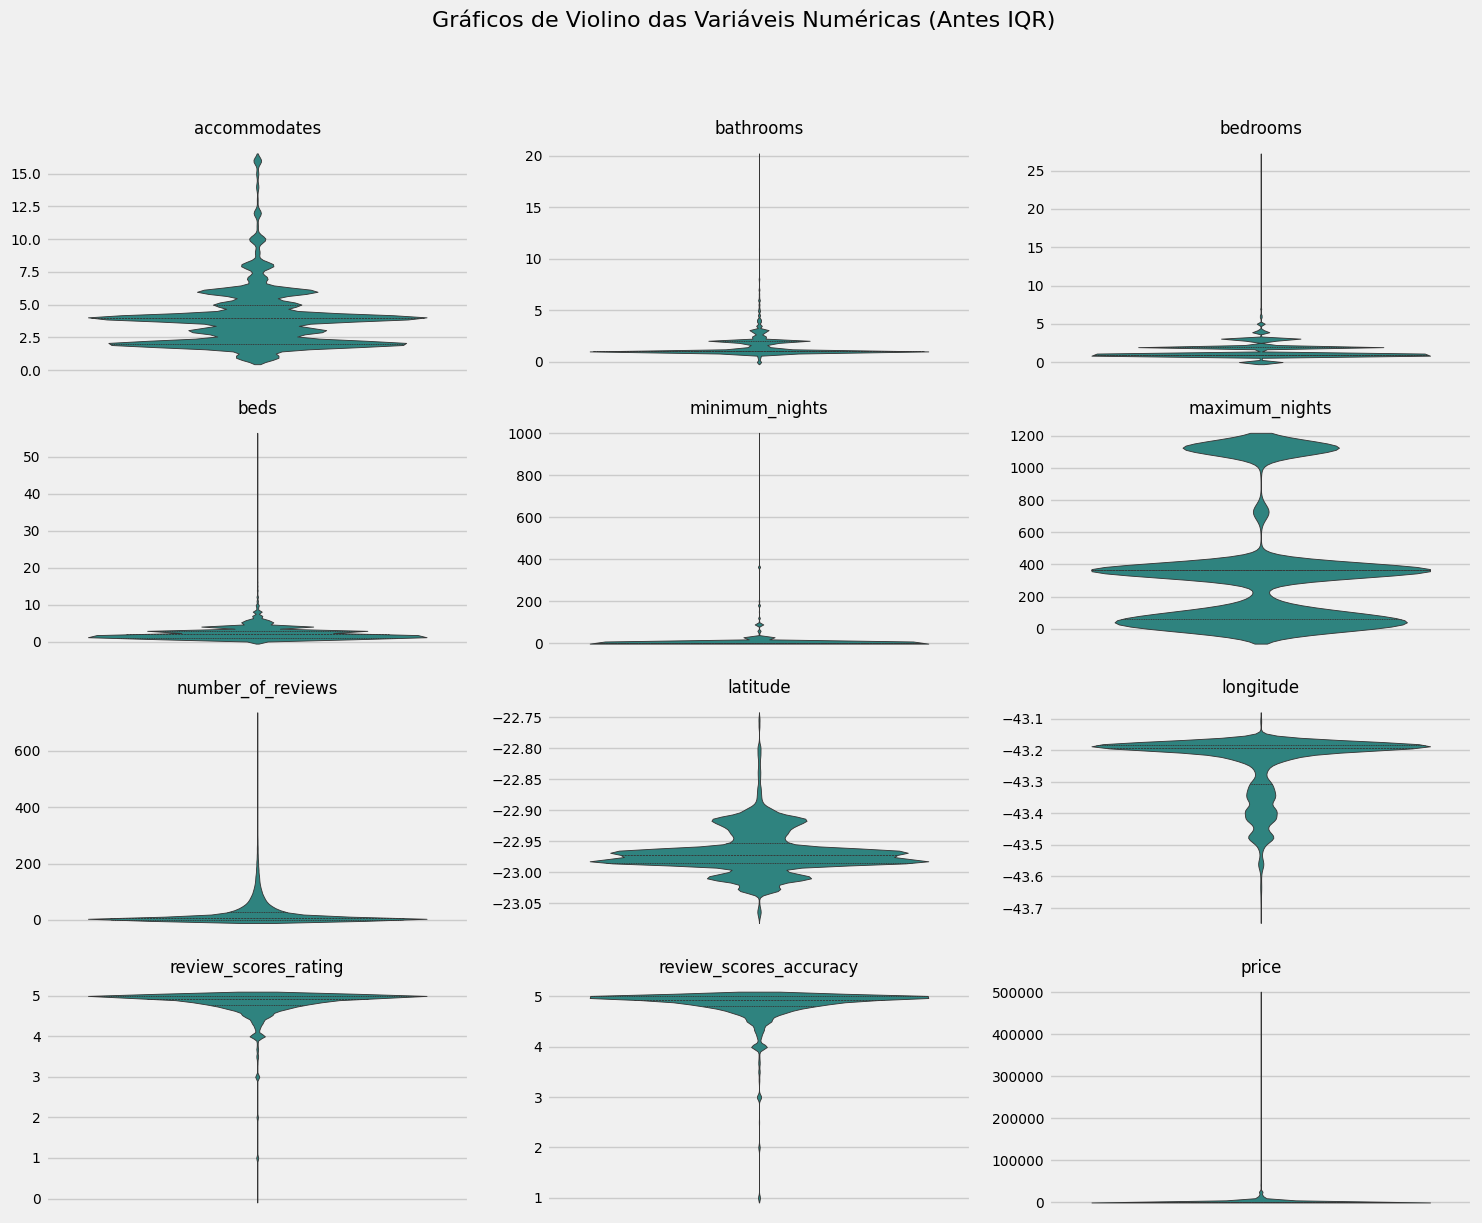

In [13]:
# --- Código para a plotagem dos Violinplots ---

# 1. Configurar a grade de plots (4 linhas, 3 colunas)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
# O método flatten() transforma a matriz 4x3 de eixos em um array para facilitar o loop
axes = axes.flatten()

# 2. Iterar sobre as colunas numéricas e criar um violinplot para cada uma
for i, col in enumerate(numeric_cols_for_iqr):
    ax = axes[i]
    # Usar sns.violinplot diretamente
    sns.violinplot(y=rio_listings[col].dropna(), ax=ax, inner="quartile", palette="viridis")
    ax.set_title(col, fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylabel('') # Remove o rótulo 'y' padrão para evitar poluição visual

# 3. Ocultar eixos que não foram usados (caso o número de plots não preencha a grade)
for i in range(len(numeric_cols_for_iqr), len(axes)):
    axes[i].set_visible(False)

# 4. Adicionar um título geral para o gráfico
fig.suptitle('Gráficos de Violino das Variáveis Numéricas (Antes IQR)', fontsize=16, y=1.02)


# 5. Ajustar o layout para evitar sobreposição e salvar o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta o layout para acomodar o suptitle
plt.savefig('violinplots_antes_iqr.png')

print("Gráfico de violino salvo com sucesso como 'violinplots_antes_iqr.png'")

In [12]:
data_iqr, _ = remove_outliers_iqr(df=rio_listings, columns=numeric_cols_for_iqr)

Gráfico de violino salvo com sucesso como 'violinplots_apos_iqr.png'


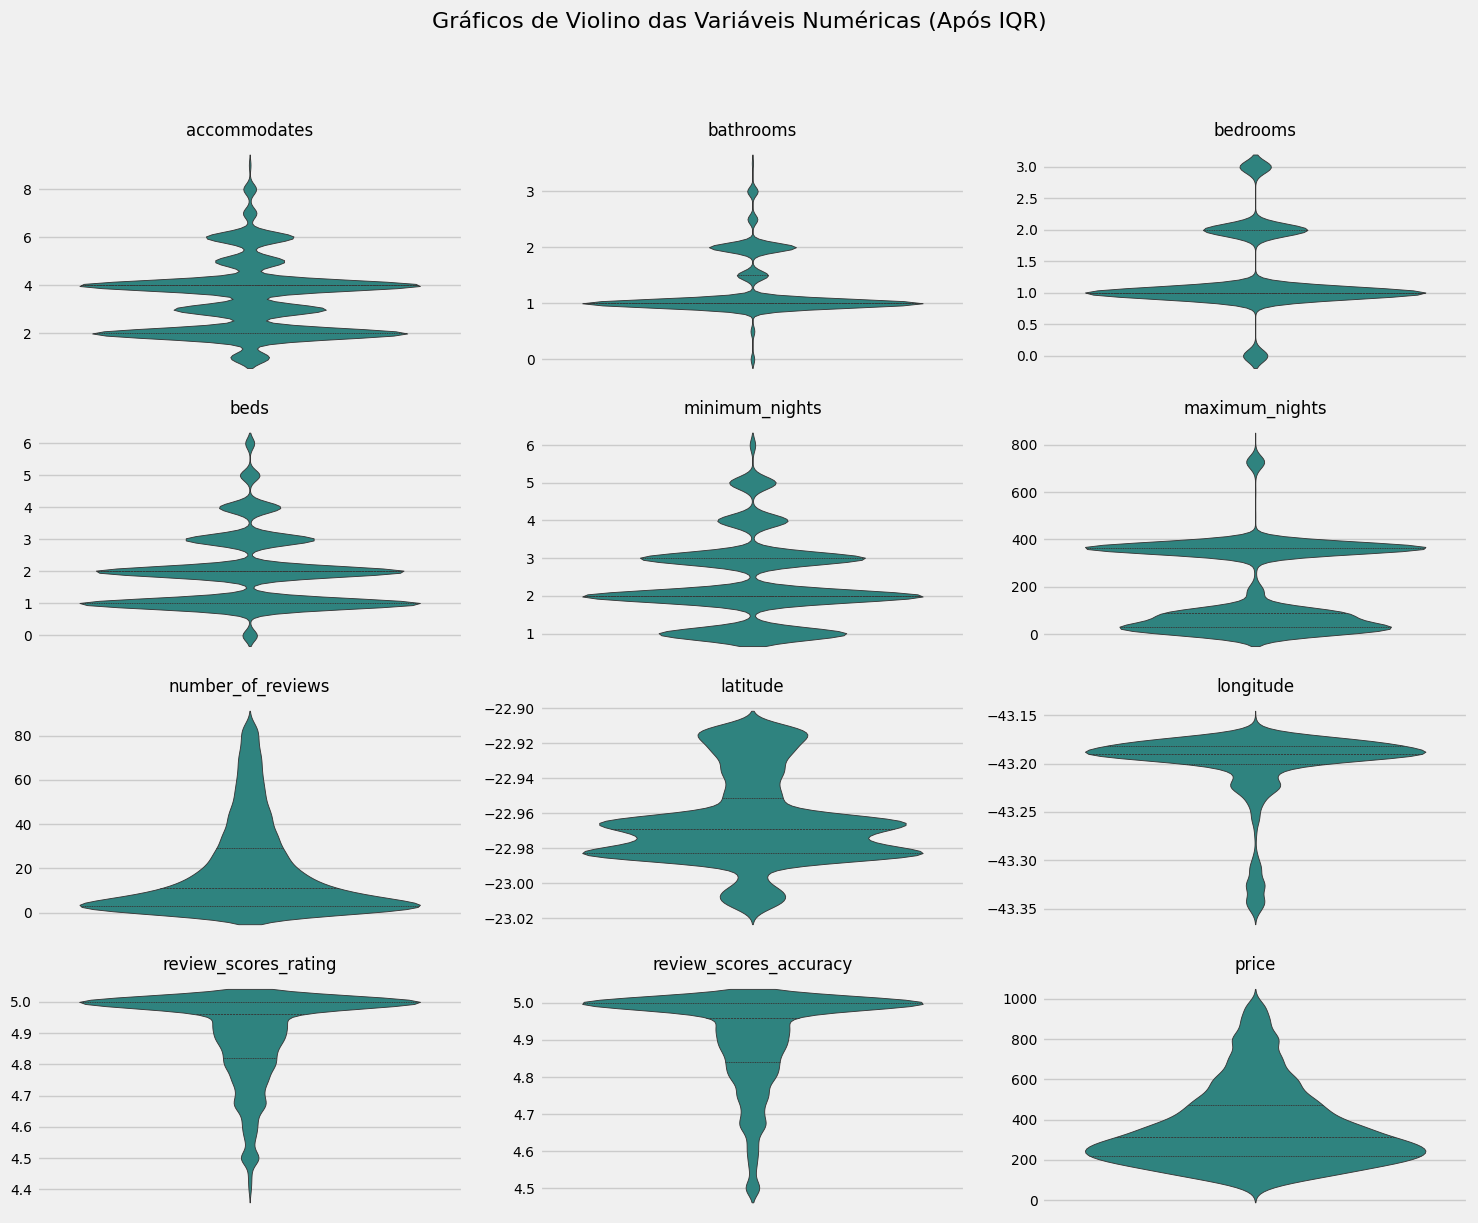

In [456]:
# --- Código para a plotagem dos Violinplots ---

# 1. Configurar a grade de plots (4 linhas, 3 colunas)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
# O método flatten() transforma a matriz 4x3 de eixos em um array para facilitar o loop
axes = axes.flatten()

# 2. Iterar sobre as colunas numéricas e criar um violinplot para cada uma
for i, col in enumerate(numeric_cols_for_iqr):
    ax = axes[i]
    # Usar sns.violinplot diretamente
    sns.violinplot(y=data_iqr[col].dropna(), ax=ax, inner="quartile", palette="viridis")
    ax.set_title(col, fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylabel('') # Remove o rótulo 'y' padrão para evitar poluição visual

# 3. Ocultar eixos que não foram usados (caso o número de plots não preencha a grade)
for i in range(len(numeric_cols_for_iqr), len(axes)):
    axes[i].set_visible(False)

# 4. Adicionar um título geral para o gráfico
fig.suptitle('Gráficos de Violino das Variáveis Numéricas (Após IQR)', fontsize=16, y=1.02)


# 5. Ajustar o layout para evitar sobreposição e salvar o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta o layout para acomodar o suptitle
plt.savefig('violinplots_apos_iqr.png')

print("Gráfico de violino salvo com sucesso como 'violinplots_apos_iqr.png'")

**Deixar como está:** `accommodates`, `bathrooms`, `bedrooms`, `beds`, `minimum_nights`, `review_scores_rating`, `review_scores_accuracy`. (Selecionar somente uma entre `accommodates`, `bathrooms`, `bedrooms` e `beds`).

**Aplicação de transformação logarítmica (np.log1p):**  `price` (seu alvo), `number_of_reviews`, `maximum_nights`.

**O ideal é criar novas features a partir delas** : `latitude` e `longitude`.
Os valores brutos de latitude e longitude são o que permite ao modelo criar "fronteiras" geográficas. No entanto, você pode ajudar o modelo a entender esses clusters de forma mais explícita.

Técnica Recomendada (Opcional, mas poderosa): Use um algoritmo de clusterização, como o K-Means, apenas com a latitude e a longitude para agrupar seus anúncios em, digamos, 5 ou 10 "zonas geográficas". Em seguida, crie uma nova coluna zona_geografica no seu DataFrame. Essa nova feature categórica pode ser extremamente poderosa.



In [458]:
data_iqr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13845 entries, 2 to 41943
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   accommodates            13845 non-null  int64  
 1   bathrooms               13845 non-null  float64
 2   bedrooms                13845 non-null  float64
 3   beds                    13845 non-null  float64
 4   minimum_nights          13845 non-null  int64  
 5   maximum_nights          13845 non-null  int64  
 6   number_of_reviews       13845 non-null  int64  
 7   latitude                13845 non-null  float64
 8   longitude               13845 non-null  float64
 9   neighbourhood_cleansed  13845 non-null  object 
 10  property_type           13845 non-null  object 
 11  room_type               13845 non-null  object 
 12  amenities               13845 non-null  object 
 13  review_scores_rating    13845 non-null  float64
 14  review_scores_accuracy  13845 non-null  flo

### --- PASSO 3: Engenharia de Features ---

In [335]:
# 1. Transformação de log no alvo
data_iqr['price_log'] = np.log1p(data_iqr['price'])
print(data_iqr['price_log'])

# 2. Transformação de log na feature `number_of_reviews`
data_iqr['number_of_reviews_log'] = np.log1p(data_iqr['number_of_reviews'])
print(data_iqr['number_of_reviews_log'])

# 3. Transformação de log na feature `maximum_nights`
data_iqr['maximum_nights_log'] = np.log1p(data_iqr['maximum_nights'])
print(data_iqr['maximum_nights_log'])

2       6.69
4       5.40
5       6.00
7       5.99
8       5.29
        ... 
41806   5.70
41853   5.53
41883   5.62
41907   5.80
41943   6.01
Name: price_log, Length: 13845, dtype: float64
2       2.64
4       3.37
5       3.61
7       3.66
8       1.39
        ... 
41806   0.69
41853   0.69
41883   1.39
41907   0.69
41943   0.69
Name: number_of_reviews_log, Length: 13845, dtype: float64
2       4.51
4       3.37
5       6.59
7       3.43
8       4.51
        ... 
41806   4.50
41853   5.90
41883   5.90
41907   5.90
41943   5.90
Name: maximum_nights_log, Length: 13845, dtype: float64


In [336]:
# 4. Criar features a partir de 'amenities'
data_iqr['amenities'] = data_iqr['amenities'].fillna('[]') # Garante que não há NaNs
data_iqr['has_wifi'] = data_iqr['amenities'].str.contains('wifi', case=False).astype(int)
data_iqr['has_ac'] = data_iqr['amenities'].str.contains('air conditioning', case=False).astype(int)
data_iqr['has_pool'] = data_iqr['amenities'].str.contains('pool', case=False).astype(int)

In [337]:
# 5. One-Hot Encoding para 'room_type'
room_type_dummies = pd.get_dummies(data_iqr['room_type'], prefix='room_type', drop_first=True) # drop_first para evitar multicolinearidade
data_final = pd.concat([data_iqr, room_type_dummies], axis=1)

In [338]:
print(data_final[['review_scores_rating', 'review_scores_accuracy']].isnull().sum())
print(len(data_final))

review_scores_rating      0
review_scores_accuracy    0
dtype: int64
13845


In [339]:
data_final["maximum_nights_log"]

2       4.51
4       3.37
5       6.59
7       3.43
8       4.51
        ... 
41806   4.50
41853   5.90
41883   5.90
41907   5.90
41943   5.90
Name: maximum_nights_log, Length: 13845, dtype: float64

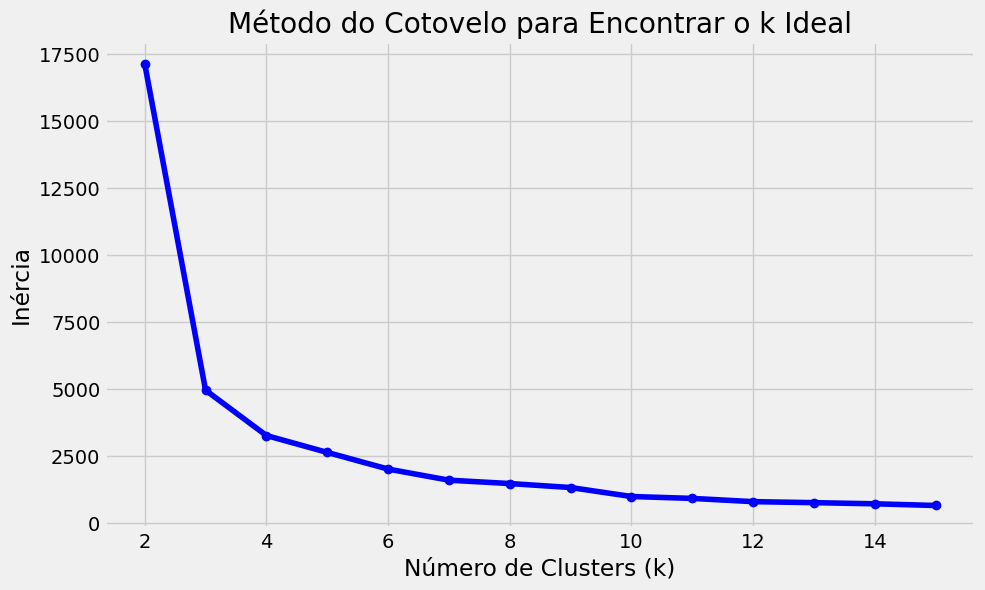

In [340]:
# Clusters geográficos de localização

# Passo 1: Preparar os Dados de Localização
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Selecionar as colunas de coordenadas
coords = data_final[['latitude', 'longitude']]

# Escalonar os dados
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Passo 2: Encontrar o Número Ideal de Clusters (k) com o "Método do Cotovelo"
# Testar de 2 a 15 clusters
inertia = []
K_range = range(2, 16)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(coords_scaled)
    inertia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Encontrar o k Ideal')
plt.grid(True)
plt.show()

In [341]:
# Passo 3: Treinar o K-Means e Criar a Nova Feature

# Escolha o 'k' ideal
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Treinar e prever os clusters
data_final['geo_cluster'] = kmeans.fit_predict(coords_scaled)

print("Nova coluna 'geo_cluster' criada com sucesso:")
print(data_final['geo_cluster'].value_counts())

Nova coluna 'geo_cluster' criada com sucesso:
geo_cluster
1    4936
3    4832
2    2970
0    1107
Name: count, dtype: int64


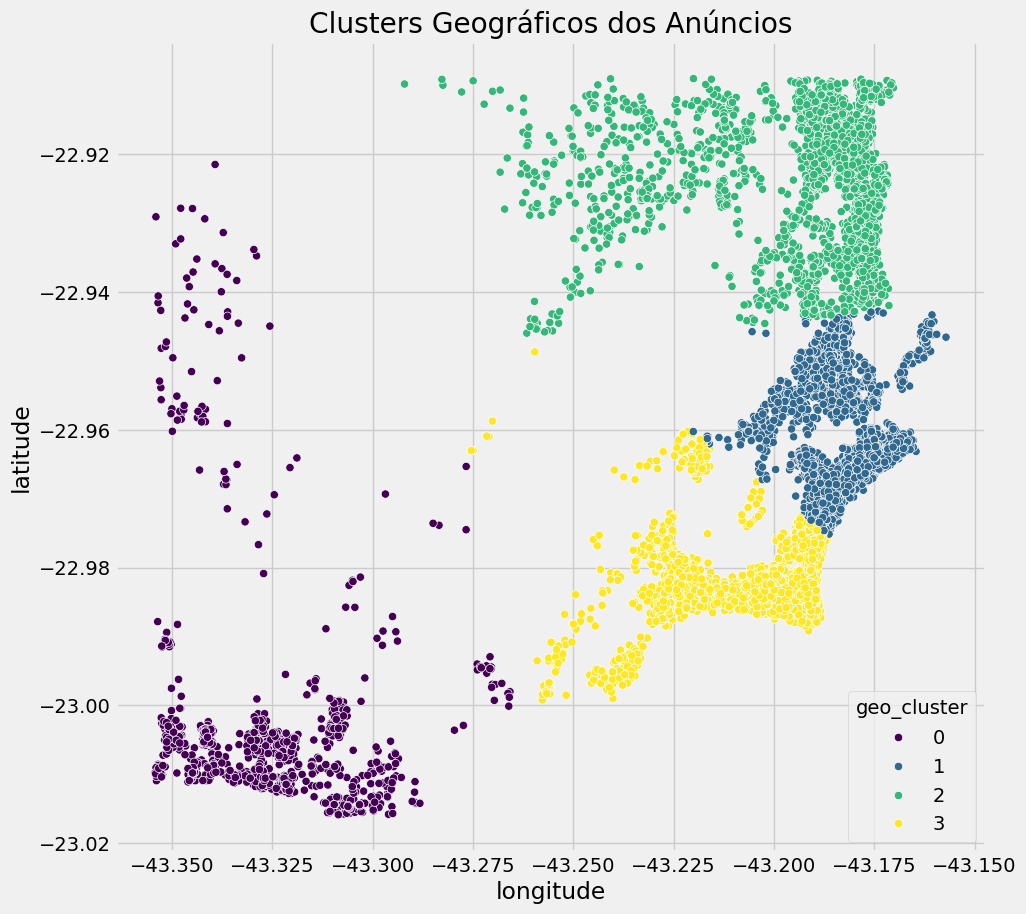

In [342]:
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='geo_cluster',
    data=data_final,
    palette='viridis',
    legend='full'
)
plt.title('Clusters Geográficos dos Anúncios')
plt.show()

In [343]:
# Aplicar One-Hot Encoding em neighbourhood_cleansed
neighbourhood_dummies = pd.get_dummies(data_final['neighbourhood_cleansed'], prefix='bairro', drop_first=True)

# Concatenar com o DataFrame final
data_final = pd.concat([data_final, neighbourhood_dummies], axis=1)

# Lembre-se de remover as colunas originais que foram transformadas antes de treinar o modelo
# Ex: 'room_type', 'neighbourhood_cleansed', 'amenities', 'price', etc.

In [344]:
data_final

,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,latitude,longitude,room_type,amenities,review_scores_rating,review_scores_accuracy,host_is_superhost,neighbourhood_cleansed,property_type,price,price_log,number_of_reviews_log,maximum_nights_log,has_wifi,has_ac,has_pool,room_type_Hotel room,room_type_Private room,room_type_Shared room,geo_cluster,bairro_Andaraí,bairro_Anil,bairro_Barra da Tijuca,bairro_Botafogo,bairro_Catete,bairro_Catumbi,bairro_Centro,bairro_Cidade Nova,bairro_Copacabana,bairro_Cosme Velho,bairro_Engenho Novo,bairro_Estácio,bairro_Flamengo,bairro_Freguesia (Jacarepaguá),bairro_Gardênia Azul,bairro_Glória,bairro_Grajaú,bairro_Gávea,bairro_Humaitá,bairro_Ipanema,bairro_Itanhangá,bairro_Jacarepaguá,bairro_Jardim Botânico,bairro_Joá,bairro_Lagoa,bairro_Laranjeiras,bairro_Leblon,bairro_Leme,bairro_Lins de Vasconcelos,bairro_Maracanã,bairro_Méier,bairro_Pechincha,bairro_Praça da Bandeira,bairro_Rio Comprido,bairro_Rocinha,bairro_Santa Teresa,bairro_São Conrado,bairro_São Cristóvão,bairro_Tijuca,bairro_Urca,bairro_Vidigal,bairro_Vila Isabel
2,7,2.00,3.00,6.00,5,90,13,-22.97,-43.19,Entire home/apt,"[""Dedicated workspace"", ""Dishes and silverware...",5.00,5.00,f,Copacabana,Entire rental unit,800.00,6.69,2.64,4.51,1,1,0,False,False,False,1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,4,1.00,1.00,2.00,2,28,28,-22.97,-43.19,Entire home/apt,"[""Dedicated workspace"", ""Clothing storage: war...",4.89,4.93,f,Copacabana,Entire rental unit,220.00,5.40,3.37,3.37,1,1,0,False,False,False,1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,2,1.00,1.00,1.00,2,730,36,-22.92,-43.19,Private room,"[""Dedicated workspace"", ""Cleaning available du...",4.94,4.89,NaN,Santa Teresa,Private room in guesthouse,401.00,6.00,3.61,6.59,1,1,0,False,True,False,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
7,4,2.00,2.00,2.00,3,30,38,-22.94,-43.19,Entire home/apt,"[""Dedicated workspace"", ""Cleaning available du...",5.00,5.00,t,Laranjeiras,Entire rental unit,399.00,5.99,3.66,3.43,1,0,0,False,False,False,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,4,1.00,1.00,2.00,4,90,3,-22.96,-43.17,Entire home/apt,"[""Dedicated workspace"", ""TV with standard cabl...",5.00,5.00,f,Leme,Entire rental unit,198.00,5.29,1.39,4.51,1,1,0,False,False,False,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41806,2,1.00,1.00,1.00,1,89,1,-22.93,-43.20,Private room,"[""Hot water"", ""Dining table"", ""Free street par...",5.00,5.00,t,Laranjeiras,Private room in bed and breakfast,297.00,5.70,0.69,4.50,1,1,0,False,True,False,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [345]:
data_final.columns

nome_do_arquivo = 'lista_de_colunas.txt'

# 3. Abra o arquivo em modo de escrita ('w') e escreva cada coluna
try:
    with open(nome_do_arquivo, 'w') as f:
        for coluna in data_final.columns:
            f.write(f"{coluna}\n") # Escreve o nome da coluna e pula uma linha
    
    print(f"Arquivo '{nome_do_arquivo}' criado com sucesso!")

except Exception as e:
    print(f"Ocorreu um erro: {e}")

Arquivo 'lista_de_colunas.txt' criado com sucesso!


--- Análise de Valores Nulos ---

Colunas que CONTÊM valores nulos: ['host_is_superhost']

Colunas que NÃO contêm valores nulos: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'latitude', 'longitude', 'room_type', 'amenities', 'review_scores_rating', 'review_scores_accuracy', 'neighbourhood_cleansed', 'property_type', 'price', 'price_log', 'number_of_reviews_log', 'maximum_nights_log', 'has_wifi', 'has_ac', 'has_pool', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'geo_cluster', 'bairro_Andaraí', 'bairro_Anil', 'bairro_Barra da Tijuca', 'bairro_Botafogo', 'bairro_Catete', 'bairro_Catumbi', 'bairro_Centro', 'bairro_Cidade Nova', 'bairro_Copacabana', 'bairro_Cosme Velho', 'bairro_Engenho Novo', 'bairro_Estácio', 'bairro_Flamengo', 'bairro_Freguesia (Jacarepaguá)', 'bairro_Gardênia Azul', 'bairro_Glória', 'bairro_Grajaú', 'bairro_Gávea', 'bairro_Humaitá', 'bairro_Ipanema', 'bairro_Itanhangá', 'bairro_

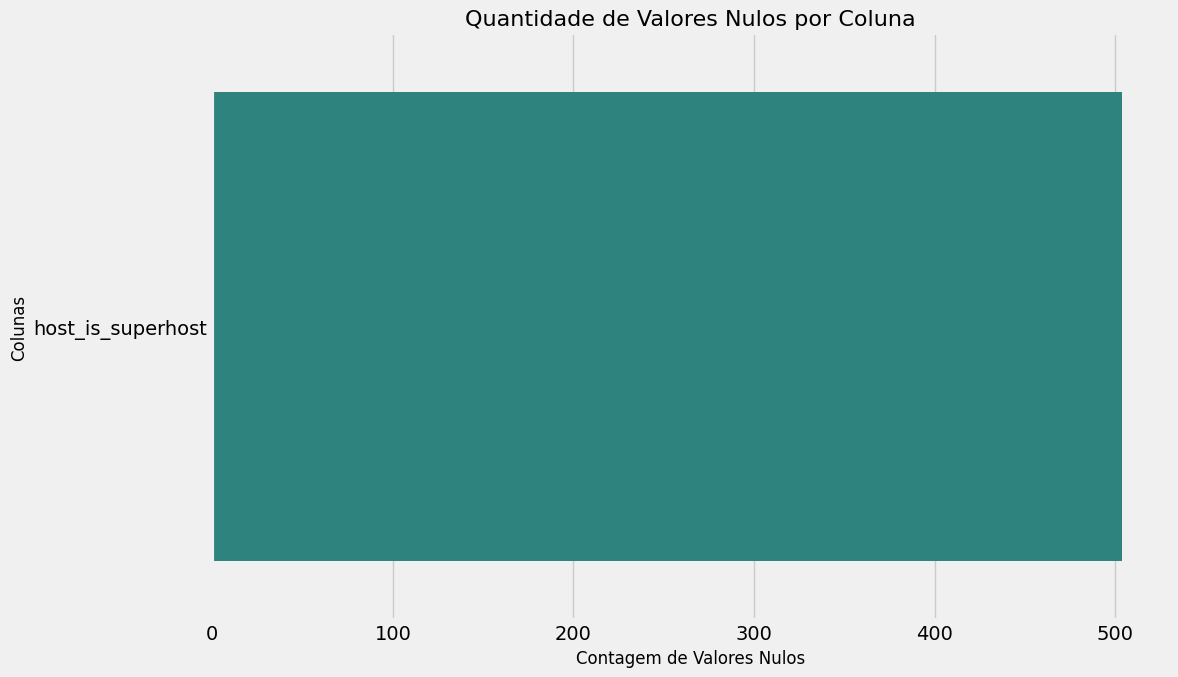

In [346]:
colunas_para_verificar = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "latitude",
    "longitude",
    "room_type",
    "amenities",
    "review_scores_rating",
    "review_scores_accuracy",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "property_type",
    "price",
    "price_log",
    "has_wifi",
    "has_ac",
    "has_pool",
    "number_of_reviews_log",
    "maximum_nights_log",
    "room_type_Hotel room",
    "room_type_Private room",
    "room_type_Shared room",
    "geo_cluster",
    "bairro_Andaraí",
    "bairro_Anil",
    "bairro_Barra da Tijuca",
    "bairro_Botafogo",
    "bairro_Catete",
    "bairro_Catumbi",
    "bairro_Centro",
    "bairro_Cidade Nova",
    "bairro_Copacabana",
    "bairro_Cosme Velho",
    "bairro_Engenho Novo",
    "bairro_Estácio",
    "bairro_Flamengo",
    "bairro_Freguesia (Jacarepaguá)",
    "bairro_Gardênia Azul",
    "bairro_Glória",
    "bairro_Grajaú",
    "bairro_Gávea",
    "bairro_Humaitá",
    "bairro_Ipanema",
    "bairro_Itanhangá",
    "bairro_Jacarepaguá",
    "bairro_Jardim Botânico",
    "bairro_Joá",
    "bairro_Lagoa",
    'bairro_Laranjeiras',
    "bairro_Leblon",
    "bairro_Leme",
    "bairro_Lins de Vasconcelos",
    "bairro_Maracanã",
    "bairro_Méier",
    "bairro_Pechincha",
    "bairro_Praça da Bandeira",
    "bairro_Rio Comprido",
    "bairro_Rocinha",
    "bairro_Santa Teresa",
    "bairro_São Conrado",
    "bairro_São Cristóvão",
    "bairro_Tijuca",
    "bairro_Urca",
    "bairro_Vidigal",
    "bairro_Vila Isabel"
]

# contagem_nulos = data_final[colunas_para_verificar].isnull().sum()
# print(contagem_nulos)

# 2. Calcular a contagem de nulos para todas as colunas
contagem_nulos_total = data_final.isnull().sum()

# 3. Filtrar para obter apenas as colunas que têm valores nulos
colunas_com_nulos = contagem_nulos_total[contagem_nulos_total > 0]

# 4. Adicionar os NOMES dessas colunas em uma variável (lista)
lista_colunas_com_nulos = colunas_com_nulos.index.tolist()

# 5. Opcional: Pegar a lista de colunas que NÃO têm nulos
colunas_sem_nulos = contagem_nulos_total[contagem_nulos_total == 0]
lista_colunas_sem_nulos = colunas_sem_nulos.index.tolist()


# --- SAÍDA E PLOTAGEM ---

# 6. Exibir as informações no console
print("--- Análise de Valores Nulos ---")
print(f"\nColunas que CONTÊM valores nulos: {lista_colunas_com_nulos}")
print(f"\nColunas que NÃO contêm valores nulos: {lista_colunas_sem_nulos}")
print("\nContagem de nulos por coluna (apenas as que têm):")
print(colunas_com_nulos)


# 7. Plotar o gráfico de barras
if not colunas_com_nulos.empty:
    plt.figure(figsize=(12, 7)) # Define o tamanho do gráfico
    
    # Criar o gráfico de barras horizontais para melhor visualização dos nomes
    sns.barplot(x=colunas_com_nulos.values, y=colunas_com_nulos.index, palette='viridis')
    
    # Adicionar títulos e rótulos
    plt.title('Quantidade de Valores Nulos por Coluna', fontsize=16)
    plt.xlabel('Contagem de Valores Nulos', fontsize=12)
    plt.ylabel('Colunas', fontsize=12)
    
    # Otimizar o layout e exibir o gráfico
    plt.tight_layout()
    plt.show()
else:
    print("\nÓtima notícia! Nenhuma coluna no DataFrame contém valores nulos.")

In [347]:
# Remover linhas com valores nulos nas colunas principais
data_final.dropna(subset=["host_is_superhost"], inplace=True)
data_final["host_is_superhost"].isnull().sum()

0

In [348]:
# Para converter para host_is_superhost para INTEIROS (1 e 0)
data_final['host_is_superhost'] = (data_final['host_is_superhost'] == 't').astype(int)

In [349]:
data_final['price_log']

2       6.69
4       5.40
7       5.99
8       5.29
12      5.77
        ... 
41806   5.70
41853   5.53
41883   5.62
41907   5.80
41943   6.01
Name: price_log, Length: 13341, dtype: float64

In [350]:
data_final[[
    # 'accommodates',   # usar beds
    # 'bathrooms',      # usar beds
    # 'bedrooms',       # usar beds
    "beds",
    "minimum_nights",
    # 'maximum_nights',    -> maximum_nights_log
    # 'number_of_reviews', -> number_of_reviews_log
    "latitude",     # manter por enquanto
    "longitude",    # manter por enquanto
    # "room_type",
    # "amenities",
    "review_scores_rating",
    "review_scores_accuracy",
    "host_is_superhost",
    # 'neighbourhood_cleansed', -> bairro_*
    # "property_type",      # nao em uso
    # 'price', 
    # 'price_log',
    "has_wifi",
    "has_ac",
    "has_pool",
    "number_of_reviews_log",
    "maximum_nights_log",
    "room_type_Hotel room",
    "room_type_Private room",
    "room_type_Shared room",
    "geo_cluster",
    "bairro_Andaraí",
    "bairro_Anil",
    "bairro_Barra da Tijuca",
    "bairro_Botafogo",
    "bairro_Catete",
    "bairro_Catumbi",
    "bairro_Centro",
    "bairro_Cidade Nova",
    "bairro_Copacabana",
    "bairro_Cosme Velho",
    "bairro_Engenho Novo",
    "bairro_Estácio",
    "bairro_Flamengo",
    "bairro_Freguesia (Jacarepaguá)",
    "bairro_Gardênia Azul",
    "bairro_Glória",
    "bairro_Grajaú",
    "bairro_Gávea",
    "bairro_Humaitá",
    "bairro_Ipanema",
    "bairro_Itanhangá",
    "bairro_Jacarepaguá",
    "bairro_Jardim Botânico",
    "bairro_Joá",
    "bairro_Lagoa",
    'bairro_Laranjeiras',
    "bairro_Leblon",
    "bairro_Leme",
    "bairro_Lins de Vasconcelos",
    "bairro_Maracanã",
    "bairro_Méier",
    "bairro_Pechincha",
    "bairro_Praça da Bandeira",
    "bairro_Rio Comprido",
    "bairro_Rocinha",
    "bairro_Santa Teresa",
    "bairro_São Conrado",
    "bairro_São Cristóvão",
    "bairro_Tijuca",
    "bairro_Urca",
    "bairro_Vidigal",
    "bairro_Vila Isabel"
]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 13341 entries, 2 to 41943
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   beds                            13341 non-null  float64
 1   minimum_nights                  13341 non-null  int64  
 2   latitude                        13341 non-null  float64
 3   longitude                       13341 non-null  float64
 4   review_scores_rating            13341 non-null  float64
 5   review_scores_accuracy          13341 non-null  float64
 6   host_is_superhost               13341 non-null  int64  
 7   has_wifi                        13341 non-null  int64  
 8   has_ac                          13341 non-null  int64  
 9   has_pool                        13341 non-null  int64  
 10  number_of_reviews_log           13341 non-null  float64
 11  maximum_nights_log              13341 non-null  float64
 12  room_type_Hotel room            13341

### Matriz de correlação

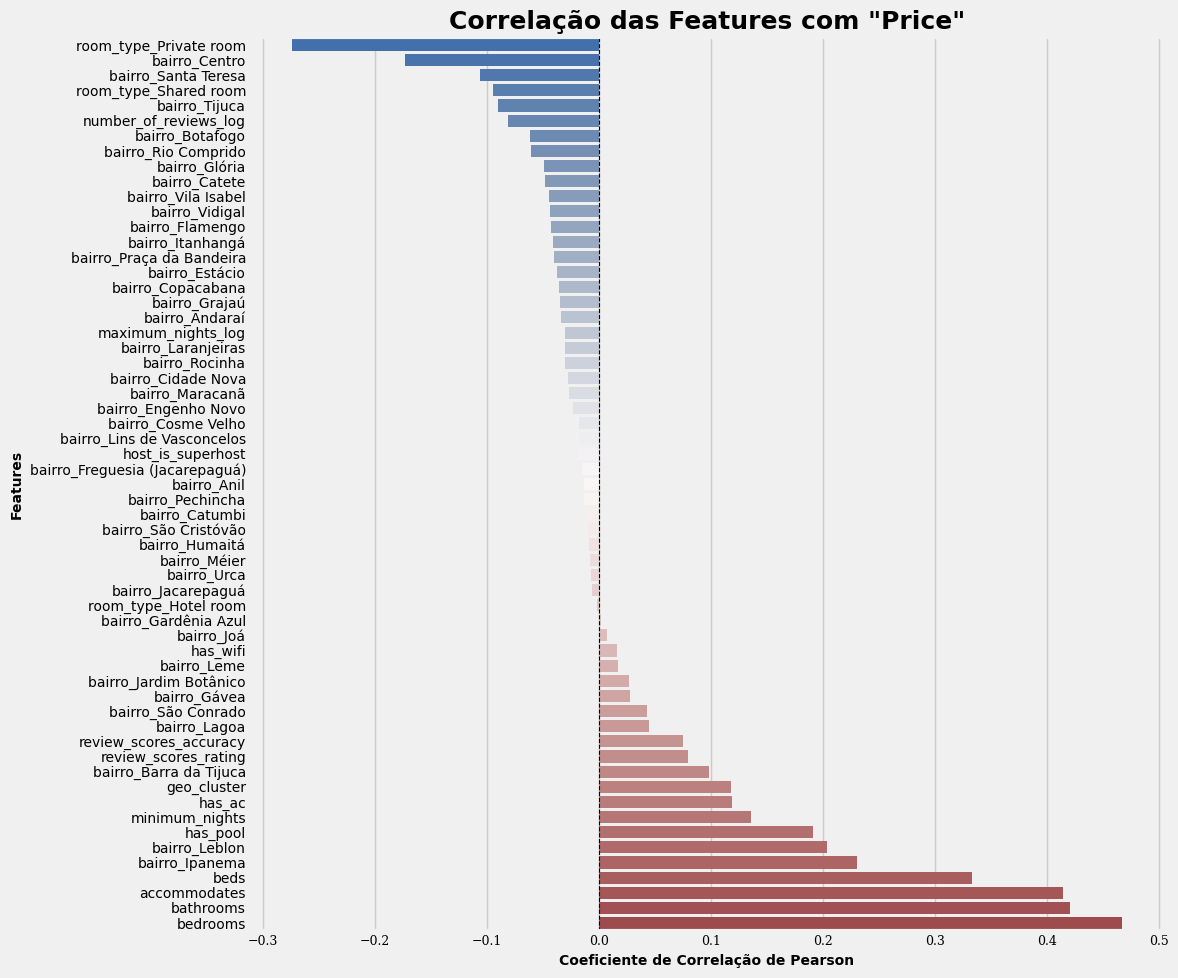

In [351]:
columns_for_corr = [
    'accommodates',   # usar beds
    'bathrooms',      # usar beds
    'bedrooms',       # usar beds
    "beds",
    "minimum_nights",
    # 'maximum_nights',         -> maximum_nights_log
    # 'number_of_reviews',      -> number_of_reviews_log
    # "latitude",     # manter por enquanto
    # "longitude",    # manter por enquanto
    # "room_type",              -> room_type_*
    # "amenities",              -> has_*
    "review_scores_rating",
    "review_scores_accuracy",
    "host_is_superhost",
    # 'neighbourhood_cleansed', -> bairro_*
    # "property_type",          # nao em uso
    'price', 
    # 'price_log',
    "has_wifi",
    "has_ac",
    "has_pool",
    "number_of_reviews_log",
    "maximum_nights_log",
    "room_type_Hotel room",
    "room_type_Private room",
    "room_type_Shared room",
    "geo_cluster",
    "bairro_Andaraí",
    "bairro_Anil",
    "bairro_Barra da Tijuca",
    "bairro_Botafogo",
    "bairro_Catete",
    "bairro_Catumbi",
    "bairro_Centro",
    "bairro_Cidade Nova",
    "bairro_Copacabana",
    "bairro_Cosme Velho",
    "bairro_Engenho Novo",
    "bairro_Estácio",
    "bairro_Flamengo",
    "bairro_Freguesia (Jacarepaguá)",
    "bairro_Gardênia Azul",
    "bairro_Glória",
    "bairro_Grajaú",
    "bairro_Gávea",
    "bairro_Humaitá",
    "bairro_Ipanema",
    "bairro_Itanhangá",
    "bairro_Jacarepaguá",
    "bairro_Jardim Botânico",
    "bairro_Joá",
    "bairro_Lagoa",
    'bairro_Laranjeiras',
    "bairro_Leblon",
    "bairro_Leme",
    "bairro_Lins de Vasconcelos",
    "bairro_Maracanã",
    "bairro_Méier",
    "bairro_Pechincha",
    "bairro_Praça da Bandeira",
    "bairro_Rio Comprido",
    "bairro_Rocinha",
    "bairro_Santa Teresa",
    "bairro_São Conrado",
    "bairro_São Cristóvão",
    "bairro_Tijuca",
    "bairro_Urca",
    "bairro_Vidigal",
    "bairro_Vila Isabel"
]


# Vamos garantir que todas as colunas existem no DataFrame para evitar erros
# (por exemplo, se 'Shared room' não apareceu no seu conjunto de dados limpo)
columns_for_corr = [col for col in columns_for_corr if col in data_final.columns]

# --- 2. Calcular a nova matriz de correlação ---
corr_matrix_expanded = data_final[columns_for_corr].corr(method="pearson")
# print(corr_matrix_expanded.loc['price',:])

price_corr_series = corr_matrix_expanded.loc['price', :].drop('price')

# --- 3. (IMPORTANTE) Ordenar os valores para uma melhor visualização ---
price_corr_sorted = price_corr_series.sort_values(ascending=True)

# --- 4. Gerar o gráfico de barras ---
plt.figure(figsize=(12, 10))

# Criar o gráfico de barras
barplot = sns.barplot(
    x=price_corr_sorted.values,
    y=price_corr_sorted.index,
    palette="vlag"
)

# Adicionar uma linha vertical em x=0
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

# Título do Gráfico (já customizado)
plt.title('Correlação das Features com "Price"', fontsize=18, fontweight='bold')

# --- Alterando a FONTE DOS TÍTULOS DOS EIXOS ---
plt.xlabel(
    'Coeficiente de Correlação de Pearson',
    fontsize=10,        # Tamanho da fonte
    fontweight='bold'   # Peso da fonte (ex: 'bold', 'light', 'normal')
)
plt.ylabel(
    'Features',
    fontsize=10,
    fontweight='bold'
)

# --- Alterando a FONTE DOS RÓTULOS DOS TICKS ---
plt.xticks(
    fontsize=9,          # Tamanho da fonte dos números no eixo X
    fontfamily='serif'  # Família da fonte (ex: 'serif', 'sans-serif', 'monospace')
)
plt.yticks(
    fontsize=10           # Tamanho da fonte dos nomes das features no eixo Y
)


plt.tight_layout()
plt.show()

Fazer testes com um dos 2:
- `review_scores_rating` e `review_scores_accuracy` -> 0.83


Fazer testes com um dos 4:
- `beds` e `bedrooms` -> 0.56
- `bedrooms` e `bathrooms` -> 0.61
- `beds` e `accomodates` -> 0.56

- **Correlação Próxima de +1.00**: Significa que quando o valor da feature aumenta, o preço tende a aumentar.

- **Correlação Próxima de -1.00**: Significa que quando o valor da feature aumenta, o preço tende a diminuir. Isso é um sinal preditivo muito forte!

- **Cuidado com a Multicolinearidade (Correlação entre as Features)**: Elas fornecem informação redundante para o modelo. Por exemplo, bedrooms (quartos) e beds (camas) provavelmente terão uma correlação muito alta entre si (ex: 0.90). Manter ambas pode "confundir" modelos lineares e tornar a interpretação dos resultados mais difícil.

- **Correlação Baixa não significa "Inútil"**: pois pode existir uma relação não-linear. Imagine uma feature onde valores muito baixos e muito altos aumentam o preço, mas valores intermediários não (uma relação em formato de "U"). A correlação de Pearson seria próxima de zero, mas um modelo baseado em árvores (como Random Forest ou XGBoost) conseguiria capturar esse padrão.

In [ ]:
# --- INÍCIO DA LÓGICA DE SELEÇÃO DE FEATURES ---

# 1. Definir o limiar de correlação
limiar = 0.1

# 2. Aplicar o filtro para selecionar features
# A forma mais fácil de pegar > 0.1 E < -0.1 é usar o valor absoluto .abs()
features_selecionadas = price_corr_series[price_corr_series.abs() >= limiar]

# 3. Criar a lista final com os nomes das colunas (o índice da Série)
final_feature_cols = features_selecionadas.index.tolist()


# --- Exibir o resultado ---
print(f"Limiar de correlação definido: {limiar}")
print(f"\nNúmero de features selecionadas: {len(final_feature_cols)}")
print("\nFeatures Finais Selecionadas:")
print(final_feature_cols)
print("\nCorrelação de cada feature selecionada com 'price':")
print(features_selecionadas.sort_values(ascending=False))

Limiar de correlação definido: 0.2

Número de features selecionadas: 7

Features Finais Selecionadas:
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'room_type_Private room', 'bairro_Ipanema', 'bairro_Leblon']

Correlação de cada feature selecionada com 'price':
bedrooms                  0.47
bathrooms                 0.42
accommodates              0.41
beds                      0.33
bairro_Ipanema            0.23
bairro_Leblon             0.20
room_type_Private room   -0.27
Name: price, dtype: float64


### --- PASSO 4: Preparar X e y para o modelo ---

In [353]:
# Selecionar as colunas de features finais
final_feature_cols = [
    "bedrooms",
    "bathrooms",
    "accommodates",
    "beds",
    "bairro_Ipanema",
    "bairro_Leblon",
    "has_pool",
    "minimum_nights",
    "has_ac",
    "geo_cluster",
    "bairro_Santa Teresa",
    "bairro_Centro",
    "room_type_Private room",
    "latitude",
    "longitude"
]

final_feature_cols

['bedrooms',
 'bathrooms',
 'accommodates',
 'beds',
 'bairro_Ipanema',
 'bairro_Leblon',
 'has_pool',
 'minimum_nights',
 'has_ac',
 'geo_cluster',
 'bairro_Santa Teresa',
 'bairro_Centro',
 'room_type_Private room',
 'latitude',
 'longitude']

In [354]:
# O novo alvo é 'price_log'
final_target_col = 'price_log'

In [355]:
# Converter para NumPy
X_final = data_final[final_feature_cols].to_numpy(dtype=np.float32)
y_final = data_final[final_target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

print(f"Formato final das features (X): {X_final.shape}")
print(f"Formato final do alvo (y): {y_final.shape}")

# A partir daqui, você pode alimentar X_final e y_final no seu pipeline do PyTorch,
# exatamente como fez antes (criando tensores, TensorDataset, random_split, etc.).
# Lembre-se que a dimensão de entrada do seu modelo (D) agora será X_final.shape[1].

Formato final das features (X): (13341, 15)
Formato final do alvo (y): (13341, 1)


In [356]:
X_final

array([[  3.      ,   2.      ,   7.      , ...,   0.      , -22.97333 ,
        -43.18857 ],
       [  1.      ,   1.      ,   4.      , ...,   0.      , -22.9682  ,
        -43.18523 ],
       [  2.      ,   2.      ,   4.      , ...,   0.      , -22.94274 ,
        -43.19016 ],
       ...,
       [  1.      ,   1.      ,   4.      , ...,   0.      , -22.969109,
        -43.182148],
       [  2.      ,   1.      ,   4.      , ...,   0.      , -22.99144 ,
        -43.23264 ],
       [  2.      ,   1.      ,   6.      , ...,   0.      , -22.964523,
        -43.179142]], dtype=float32)

# DataFrame de Resultados

In [357]:
# Crie um DataFrame vazio com as colunas que queremos salvar
results_df = pd.DataFrame(columns=[
    'timestamp', 'normalization', 'optimizer', 'lr',
    'epochs', 'batch_size', 'mae', 'rmse', 'r2', 'mape'
])

# Para exibir todas as colunas quando printarmos o DataFrame
pd.set_option('display.max_columns', None)

In [ ]:
# Esta função vai encapsular todo o processo. Ela receberá os parâmetros do experimento (tipo de normalização, otimizador, etc.), treinará o modelo e retornará um dicionário com os resultados.
import torch.optim as optim

def run_experiment(X_data, y_data, normalization_type, optimizer_type, lr, n_epochs, batch_size):
    """
    Executa um ciclo completo de treinamento e teste com os parâmetros especificados.
    AGORA RECEBE X_data e y_data COMO PARÂMETROS.
    """
    print(f"--- Iniciando Experimento ---")
    print(f"Normalização: {normalization_type}, Otimizador: {optimizer_type}, LR: {lr}, Épocas: {n_epochs}, Batch: {batch_size}")

    # --- 1. Preparação e Divisão dos Dados ---
    torch.manual_seed(13)
    # USA OS PARÂMETROS DA FUNÇÃO DIRETAMENTE
    x_tensor = torch.as_tensor(X_data).float()
    y_tensor = torch.as_tensor(y_data).float()
    dataset = TensorDataset(x_tensor, y_tensor)

    # Divisão em Treino, Validação e Teste
    n_total = len(dataset)
    n_train = int(n_total * 0.70)
    n_val = int(n_total * 0.15)
    n_test = n_total - n_train - n_val
    train_data_raw, val_data_raw, test_data_raw = random_split(dataset, [n_train, n_val, n_test])

    # --- 2. Normalização Condicional ---
    train_idx = train_data_raw.indices
    eps = 1e-8

    if normalization_type == 'z_score':
        # Normalização Z-score (como antes)
        mu = x_tensor[train_idx].mean(dim=0)
        std = x_tensor[train_idx].std(dim=0, unbiased=False)
        std = torch.where(std < eps, torch.ones_like(std), std)
        x_tensor_norm = (x_tensor - mu) / std

        y_mu = y_tensor[train_idx].mean(dim=0)
        y_std = y_tensor[train_idx].std(dim=0, unbiased=False)
        y_std = torch.where(y_std < eps, torch.ones_like(y_std), y_std)
        y_tensor_norm = (y_tensor - y_mu) / y_std

    elif normalization_type == 'min_max':
        # Nova opção: Normalização Min-Max
        min_val = x_tensor[train_idx].min(dim=0, keepdim=True).values
        max_val = x_tensor[train_idx].max(dim=0, keepdim=True).values
        range_val = max_val - min_val
        range_val = torch.where(range_val < eps, torch.ones_like(range_val), range_val)
        x_tensor_norm = (x_tensor - min_val) / range_val

        # A normalização do alvo (y) geralmente é melhor com Z-score, mas podemos testar Min-Max também
        y_min_val = y_tensor[train_idx].min(dim=0, keepdim=True).values
        y_max_val = y_tensor[train_idx].max(dim=0, keepdim=True).values
        y_range_val = y_max_val - y_min_val
        y_range_val = torch.where(y_range_val < eps, torch.ones_like(y_range_val), y_range_val)
        y_tensor_norm = (y_tensor - y_min_val) / y_range_val

    # Recriar datasets com dados normalizados
    dataset_norm = TensorDataset(x_tensor_norm, y_tensor_norm)
    train_data = Subset(dataset_norm, train_data_raw.indices)
    val_data = Subset(dataset_norm, val_data_raw.indices)
    test_data = Subset(dataset_norm, test_data_raw.indices)

    # DataLoaders
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_data, batch_size=batch_size)
    test_loader = DataLoader(dataset=test_data, batch_size=batch_size)

    # --- 3. Configuração e Treinamento do Modelo ---
    torch.manual_seed(42)
    D = x_tensor.shape[1]
    model = nn.Sequential(nn.Linear(D, 1))

    # Otimizador Condicional
    # if optimizer_type == 'SGD':
    #     optimizer = optim.SGD(model.parameters(), lr=lr)
    # elif optimizer_type == 'AdamW':
    #     optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    # elif optimizer_type == 'Adam':
    #     optimizer = optim.Adam(model.parameters(), lr=lr)
    
    if optimizer_type == 'SGD':     # Stochastic Gradient Descent
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)  # momentum melhora bastante
    elif optimizer_type == 'SGD_Nesterov':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)
    elif optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    elif optimizer_type == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)  # bom para regularização
    elif optimizer_type == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, momentum=0.9)
    elif optimizer_type == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    elif optimizer_type == 'Adadelta':
        optimizer = optim.Adadelta(model.parameters(), lr=lr)
    elif optimizer_type == 'Rprop':
        optimizer = optim.Rprop(model.parameters(), lr=lr)
    elif optimizer_type == 'LBFGS':
        optimizer = optim.LBFGS(model.parameters(), lr=lr)  # bom p/ datasets pequenos
    else:
        raise ValueError(f"Otimizador '{optimizer_type}' não suportado.")

    loss_fn = nn.MSELoss(reduction='mean')

    arch = Architecture(model, loss_fn, optimizer)
    arch.set_loaders(train_loader, val_loader)
    arch.train(n_epochs=n_epochs)

    # --- 4. Teste e Avaliação ---
    true_values, predictions = [], []
    arch.model.eval()
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(arch.device)
            y_hat_norm = arch.model(x_batch)
            predictions.append(y_hat_norm.cpu().numpy())
            true_values.append(y_batch.cpu().numpy())

    predictions_norm = np.concatenate(predictions)
    true_values_norm = np.concatenate(true_values)

    # Reverter normalização
    if normalization_type == 'z_score':
        y_pred_log = predictions_norm * y_std.numpy() + y_mu.numpy()
        y_true_log = true_values_norm * y_std.numpy() + y_mu.numpy()
    elif normalization_type == 'min_max':
        y_pred_log = predictions_norm * y_range_val.numpy() + y_min_val.numpy()
        y_true_log = true_values_norm * y_range_val.numpy() + y_min_val.numpy()

    y_pred_real = np.expm1(y_pred_log)
    y_true_real = np.expm1(y_true_log)

    # Calcular métricas
    mae = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    r2 = r2_score(y_true_real, y_pred_real)
    mape = mean_absolute_percentage_error(y_true_real, y_pred_real)

    # --- 5. Retornar Resultados ---

    # dicionário para guardar os parâmetros de normalização usados
    norm_params = {}
    if normalization_type == 'z_score':
        norm_params['mu'] = mu
        norm_params['std'] = std
        norm_params['y_mu'] = y_mu
        norm_params['y_std'] = y_std
    elif normalization_type == 'min_max':
        norm_params['min_val'] = min_val
        norm_params['max_val'] = max_val
        norm_params['range_val'] = range_val
        norm_params['y_min_val'] = y_min_val
        norm_params['y_max_val'] = y_max_val
        norm_params['y_range_val'] = y_range_val

    results = {
        'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'normalization': normalization_type,
        'optimizer': optimizer_type,
        'lr': lr,
        'epochs': n_epochs,
        'batch_size': batch_size,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'norm_params': norm_params,
        'trained_model': arch
    }

    print("--- Experimento Concluído --- \n")
    return results

# Experimentos

In [420]:
exp1_results = run_experiment(
    X_final,
    y_final,
    normalization_type='min_max',
    optimizer_type='SGD',
    lr=0.001,
    n_epochs=400,
    batch_size=32
)
results_df.loc[len(results_df)] = exp1_results

--- Iniciando Experimento ---
Normalização: min_max, Otimizador: SGD, LR: 0.001, Épocas: 400, Batch: 32
--- Experimento Concluído --- 



In [ ]:
# --- Visualizar e Salvar os resultados ---
display(results_df)

,timestamp,normalization,optimizer,lr,epochs,batch_size,mae,rmse,r2,mape
0,2025-09-28 17:58:51,z_score,Adam,0.00,100,16,112.27,160.28,0.36,0.33
1,2025-09-28 18:01:01,z_score,AdamW,0.00,100,16,112.27,160.28,0.36,0.33
2,2025-09-28 18:08:56,z_score,AdamW,0.00,100,16,112.27,160.28,0.36,0.33
3,2025-09-28 18:09:39,z_score,SGD,0.00,100,16,112.00,159.89,0.37,0.33
4,2025-09-28 18:10:36,z_score,SGD_Nesterov,0.00,100,16,113.54,162.23,0.35,0.33
5,2025-09-28 18:11:25,z_score,AdamW,0.00,100,16,112.27,160.28,0.36,0.33
6,2025-09-28 18:13:23,z_score,RMSprop,0.00,100,16,114.28,163.91,0.33,0.33
7,2025-09-28 18:14:02,z_score,Adagrad,0.00,100,16,114.92,164.24,0.33,0.34
8,2025-09-28 18:14:49,z_score,Adadelta,0.00,100,16,130.19,181.68,0.18,0.40
9,2025-09-28 18:15:53,z_score,Rprop,0.00,100,16,118.88,168.88,0.29,0.35


In [422]:
results_df.to_csv('resultados_experimentos_sequencial_1n.csv', index=False)

In [430]:
final_feature_cols_with_price = [
    "bedrooms",
    "bathrooms",
    "accommodates",
    "beds",
    "bairro_Ipanema",
    "bairro_Leblon",
    "has_pool",
    "minimum_nights",
    "has_ac",
    "geo_cluster",
    "bairro_Santa Teresa",
    "bairro_Centro",
    "room_type_Private room",
    "latitude",
    "longitude",
    "price"
]

data_final[final_feature_cols_with_price] 

,bedrooms,bathrooms,accommodates,beds,bairro_Ipanema,bairro_Leblon,has_pool,minimum_nights,has_ac,geo_cluster,bairro_Santa Teresa,bairro_Centro,room_type_Private room,latitude,longitude,price
2,3.00,2.00,7,6.00,False,False,0,5,1,1,False,False,False,-22.97,-43.19,800.00
4,1.00,1.00,4,2.00,False,False,0,2,1,1,False,False,False,-22.97,-43.19,220.00
7,2.00,2.00,4,2.00,False,False,0,3,0,2,False,False,False,-22.94,-43.19,399.00
8,1.00,1.00,4,2.00,False,False,0,4,1,1,False,False,False,-22.96,-43.17,198.00
12,1.00,1.00,2,2.00,False,False,0,2,0,1,False,False,False,-22.96,-43.17,320.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41806,1.00,1.00,2,1.00,False,False,0,1,1,2,False,False,True,-22.93,-43.20,297.00
41853,1.00,1.00,2,1.00,True,False,0,1,1,3,False,False,False,-22.98,-43.20,251.00
41883,1.00,1.00,4,1.00,False,False,0,1,1,1,False,False,False,-22.97,-43.18,275.00
41907,2.00,1.00,4,2.00,False,False,1,1,1,3,False,False,False,-22.99,-43.23,329.00


In [431]:
import numpy as np
import torch

# --------------------------------------------------------------------------
# 1. Defina o novo exemplo com as 13 features na ordem correta
# --------------------------------------------------------------------------
X_new = np.array([[
    3.0,      # bedrooms → 2 quartos
    2.0,      # bathrooms → 2 banheiros
    7.0,      # accommodates → 4 hóspedes
    6.0,      # beds → 2 camas
    0.0,      # bairro_Ipanema → não
    0.0,      # bairro_Leblon → sim
    0.0,      # has_pool → não
    5.0,      # minimum_nights → 3 noites
    1.0,      # has_ac → sim
    1.0,      # geo_cluster → ex: cluster 2
    0.0,      # bairro_Santa Teresa → não
    0.0,      # bairro_Centro → não
    0.0,      # room_type_Private room → sim
    -22.97,   # latitude → exemplo Rio de Janeiro
    -43.19    # longitude → exemplo Rio de Janeiro
]], dtype=np.float32)

# Verificação da forma (deve ser (1, 13) para 13 features)
print(f"Shape do novo X_new: {X_new.shape}")

# --------------------------------------------------------------------------
# 2. O restante do seu código de predição
# (assumindo que 'exp_results' contém os resultados do seu experimento)
# --------------------------------------------------------------------------
# # Descomente e execute esta parte quando tiver seus resultados
# # Extraia os objetos necessários dos resultados do experimento
normalization_type = exp1_results['normalization']
params = exp1_results['norm_params']
trained_arch = exp1_results['trained_model']

X_new_t = torch.as_tensor(X_new)

# # Aplicar a MESMA normalização de features do treino
if normalization_type == 'z_score':
    X_new_norm = (X_new_t - params['mu']) / params['std']
elif normalization_type == 'min_max':
    X_new_norm = (X_new_t - params['min_val']) / params['range_val']

# # Prever com o modelo treinado
X_new_norm = X_new_norm.to(trained_arch.device)
y_pred_norm = trained_arch.model(X_new_norm)
y_pred_norm = y_pred_norm.cpu().detach().numpy()

# # Reverter a normalização do alvo para a unidade original
if normalization_type == 'z_score':
    y_pred_log = y_pred_norm * params['y_std'].numpy() + params['y_mu'].numpy()
elif normalization_type == 'min_max':
    y_pred_log = y_pred_norm * params['y_range_val'].numpy() + params['y_min_val'].numpy()

# # Reverter a transformação logarítmica final (expm1)
y_pred_real = np.expm1(y_pred_log)
y_pred_real_value = float(y_pred_real.squeeze())

# ---------------------------------------------------------
# 3. Preço real esperado (defina manualmente ou traga do dataset)
# ---------------------------------------------------------
# Exemplo: suponha que o preço esperado seja R$ 450,00
y_real_value = 800.0  

# ---------------------------------------------------------
# 4. Comparar real vs previsto
# ---------------------------------------------------------
print(f"\nTipo de Normalização Usada: {normalization_type}")
print(f"Preço Previsto: R$ {y_pred_real_value:.2f}")
print(f"Preço Esperado: R$ {y_real_value:.2f}")
print(f"Erro Absoluto: R$ {abs(y_pred_real_value - y_real_value):.2f}")
print(f"Erro Percentual: {100 * abs(y_pred_real_value - y_real_value) / y_real_value:.2f}%")

Shape do novo X_new: (1, 15)

Tipo de Normalização Usada: min_max
Preço Previsto: R$ 629.92
Preço Esperado: R$ 800.00
Erro Absoluto: R$ 170.08
Erro Percentual: 21.26%


# LazyPredict

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Dados originais (como antes)
X_lazy = X_final
y_lazy_log = data_final['price_log'].to_numpy()

# Divisão principal 80/20
X_train_full, X_test, y_train_full, y_test_log = train_test_split(
    X_lazy, y_lazy_log, test_size=0.2, random_state=42
)

# --- NOVO PASSO: Criar uma amostra menor para o LazyPredict ---
# Vamos usar apenas 30% dos dados de treino para o teste rápido
_, X_train_sample, _, y_train_sample = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42
)


print(f"Formato dos dados de treino COMPLETOS: X_train_full={X_train_full.shape}")
print(f"Formato dos dados de treino para AMOSTRA: X_train_sample={X_train_sample.shape}")
print(f"Formato dos dados de teste: X_test={X_test.shape}, y_test_log={y_test_log.shape}")

Formato dos dados de treino COMPLETOS: X_train_full=(10672, 15)
Formato dos dados de treino para AMOSTRA: X_train_sample=(3202, 15)
Formato dos dados de teste: X_test=(2669, 15), y_test_log=(2669,)


In [ ]:
!pip install lazypredict

In [ ]:
from lazypredict.Supervised import LazyRegressor

reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Usando a amostra menor para o fit
models, predictions_log = reg.fit(X_train_sample, X_test, y_train_sample, y_test_log)

print("--- Desempenho dos Modelos (rodando em uma amostra de 30% dos dados) ---")
display(models)

  0%|          | 0/42 [00:00<?, ?it/s]

--- Desempenho dos Modelos (rodando em uma amostra de 30% dos dados) ---


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GradientBoostingRegressor,0.47,0.48,0.39,0.42
LGBMRegressor,0.46,0.46,0.40,0.09
RandomForestRegressor,0.45,0.46,0.40,1.30
HistGradientBoostingRegressor,0.45,0.46,0.40,0.31
LassoLarsIC,0.45,0.45,0.40,0.03
ElasticNetCV,0.45,0.45,0.40,0.16
LarsCV,0.45,0.45,0.40,0.05
LassoLarsCV,0.45,0.45,0.40,0.06
LassoCV,0.45,0.45,0.40,0.15


In [ ]:
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LassoLarsIC
from lightgbm import LGBMRegressor
import numpy as np

# --- Reverter log (ajuste de acordo com sua transformação) ---
# Se você usou np.log(y):
def revert_log(y):
    return np.exp(y)

# Caso tenha usado np.log1p(y), troque por:
# def revert_log(y):
#     return np.expm1(y)

# --- Dicionário com os modelos ---
modelos = {
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "LGBMRegressor": LGBMRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42, n_jobs=-1),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=42),
    "LassoLarsIC": LassoLarsIC()
}

resultados = {}

for nome, modelo in modelos.items():
    # Treina no espaço log
    modelo.fit(X_train_sample, y_train_sample)
    y_pred_log = modelo.predict(X_test)
    
    # Reverte para reais
    y_test_reais = revert_log(y_test_log)
    y_pred_reais = revert_log(y_pred_log)
    
    # Calcula RMSE em reais
    rmse_reais = root_mean_squared_error(y_test_reais, y_pred_reais)
    resultados[nome] = rmse_reais
    print(f"{nome}: RMSE em reais = R$ {rmse_reais:,.2f}")

# Resultados organizados em DataFrame
df_resultados = pd.DataFrame.from_dict(resultados, orient="index", columns=["RMSE (R$)"])
display(df_resultados.sort_values(by="RMSE (R$)"))


GradientBoostingRegressor: RMSE em reais = R$ 306.96
LGBMRegressor: RMSE em reais = R$ 304.28
RandomForestRegressor: RMSE em reais = R$ 289.27
HistGradientBoostingRegressor: RMSE em reais = R$ 309.27
LassoLarsIC: RMSE em reais = R$ 284.06


,RMSE (R$)
LassoLarsIC,284.06
RandomForestRegressor,289.27
LGBMRegressor,304.28
GradientBoostingRegressor,306.96
HistGradientBoostingRegressor,309.27
